In [1]:
import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
%matplotlib inline

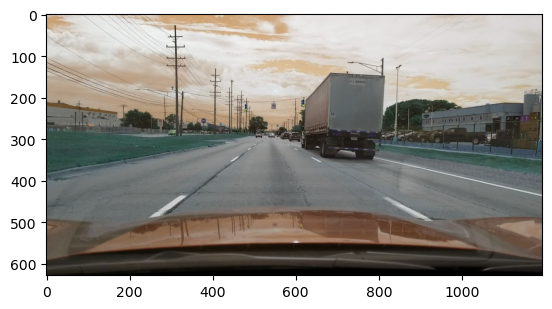

In [2]:
image_color = cv2.imread('Find_Truck_color.jpg')
height, width = image_color.shape[:2]
plt.imshow(image_color)

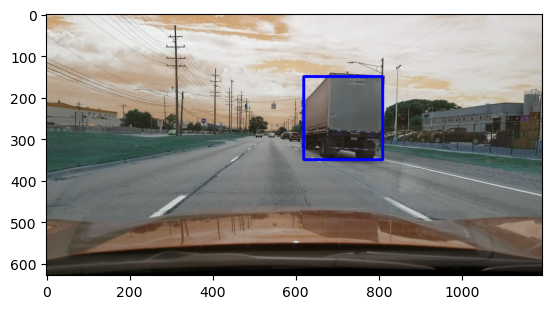

In [3]:
# Draw a box around the object (if found)
top_left = (620, 150)
bottom_right = (810, 350)
cv2.rectangle(
    image_color, 
    top_left, 
    bottom_right, 
    (0,0,255), # this is red in opencv
    5 # thickness  
)

# cv2.imshow('Truck Located!', image_color)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(image_color)

In [4]:
# LOCATE A TRUCK USING TEMPLATE MATCHING -----------------

In [5]:
import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
%matplotlib inline

image_color = cv2.imread('Find_Truck_color.jpg')
# image_color = mpimg.imread('Find_Truck_color.jpg') # import image as RGB instead of BGR 

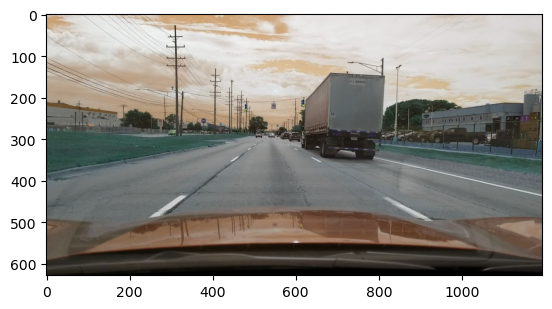

In [6]:
plt.imshow(image_color)

In [7]:
height, width = image_color.shape[:2]

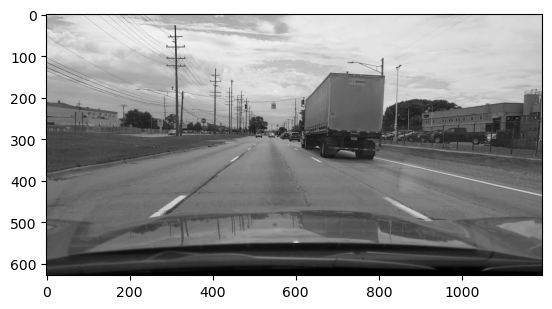

In [8]:
image_gray = cv2.cvtColor(image_color, cv2.COLOR_RGB2GRAY)
plt.imshow(image_gray, cmap = 'gray')

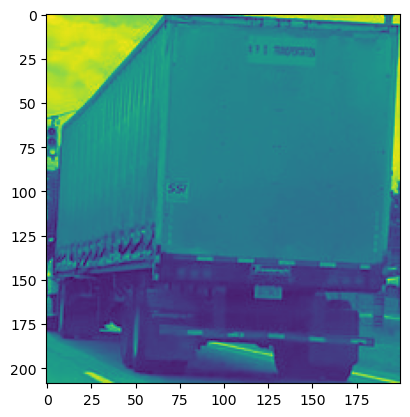

In [9]:
# Load Template image
template = cv2.imread('Truck_template.jpg',0)
plt.imshow(template)

In [10]:
template.shape

(209, 200)

In [11]:
h, w = template.shape[:]
print(h, w)

209 200


In [12]:
# Perform template matching!
result = cv2.matchTemplate(image_gray, template, cv2.TM_CCOEFF_NORMED)
result.shape

(420, 995)

In [13]:
cv2.imshow('Matching Results', result)
cv2.waitKey()
cv2.destroyAllWindows()

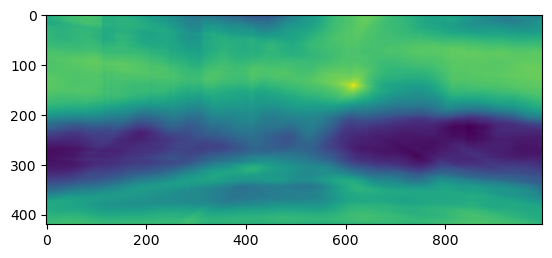

In [14]:
plt.imshow(result)
# we see a very bright dot, that's the location where the template is found in the image
# specifically: that's the top left corner of the template (which is placed on the image)


In [16]:
# Find the indices of the object to be find 
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

# max_loc: location of the MAXIMUM value (the brightest point)
# --> it's the top-left corner of the template in the image
max_loc

(616, 142)

In [17]:
# Draw a box around the object (if found)
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)
cv2.rectangle(image_color, top_left, bottom_right, (0,0,255), 5)

array([[[204, 185, 170],
        [206, 187, 172],
        [209, 190, 175],
        ...,
        [214, 210, 209],
        [214, 210, 209],
        [212, 210, 209]],

       [[215, 196, 181],
        [216, 198, 181],
        [218, 200, 183],
        ...,
        [214, 210, 209],
        [215, 211, 210],
        [213, 211, 210]],

       [[219, 199, 182],
        [217, 199, 182],
        [218, 200, 183],
        ...,
        [215, 211, 210],
        [216, 212, 211],
        [214, 212, 211]],

       ...,

       [[ 34,  31,  26],
        [ 34,  31,  26],
        [ 34,  31,  26],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[ 33,  30,  25],
        [ 33,  30,  25],
        [ 33,  30,  25],
        ...,
        [  1,   1,   1],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 32,  29,  24],
        [ 32,  29,  24],
        [ 31,  28,  23],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

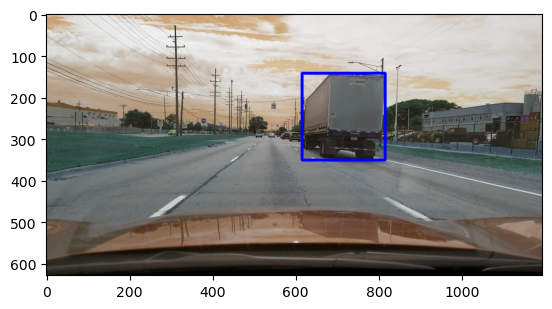

In [18]:
plt.imshow(image_color)